In [6]:
import pathlib
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
from pystac_client import Client

catalog_url = 'https://catalog.maap.eo.esa.int/catalogue/'
catalog = Client.open(catalog_url)
EC_COLLECTION = ['EarthCAREL2Validated_MAAP']

import requests
import fsspec

CREDENTIALS_FILE = (pathlib.Path.home() / "credentials.txt" ).resolve()   # Insert the .txt path
io_params = {
    "fsspec_params": {
        "cache_type": "blockcache",
        "block_size": 8 * 1024 * 1024
    },
    "h5py_params": {
        "driver_kwds": {
            "rdcc_nbytes": 8 * 1024 * 1024
        }
    }
}

def load_credentials(file_path=CREDENTIALS_FILE):
    """Read key-value pairs from a credentials file into a dictionary."""
    creds = {}
    if not file_path.exists():
        raise FileNotFoundError(f"Credentials file not found: {file_path}")
    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            if "=" not in line:
                continue
            key, value = line.split("=", 1)
            creds[key.strip()] = value.strip()
    return creds


# --- ESA MAAP API ---

def get_token():
    """Use OFFLINE_TOKEN to fetch a short-lived access token."""
    creds = load_credentials()

    OFFLINE_TOKEN = creds.get("OFFLINE_TOKEN")
    CLIENT_ID = creds.get("CLIENT_ID")
    CLIENT_SECRET = creds.get("CLIENT_SECRET")
    # print(CLIENT_SECRET)

    if not all([OFFLINE_TOKEN, CLIENT_ID, CLIENT_SECRET]):
        raise ValueError("Missing OFFLINE_TOKEN, CLIENT_ID, or CLIENT_SECRET in credentials file")

    url = "https://iam.maap.eo.esa.int/realms/esa-maap/protocol/openid-connect/token"
    data = {
        "client_id": CLIENT_ID,
        "client_secret": CLIENT_SECRET,
        "grant_type": "refresh_token",
        "refresh_token": OFFLINE_TOKEN,
        "scope": "offline_access openid"
    }

    response = requests.post(url, data=data)
    response.raise_for_status()

    response_json = response.json()
    access_token = response_json.get('access_token')

    if not access_token:
        raise RuntimeError("Failed to retrieve access token from IAM response")

    return access_token

token = get_token()
fs = fsspec.filesystem(
    "https", 
    headers={"Authorization": f"Bearer {token}"}, 
    **io_params["fsspec_params"], 
)

from contextlib import contextmanager

@contextmanager
def read_ec_file(filename):
    try:
        f = fs.open(filename)
        ds = xr.open_dataset(
            f, 
            engine="h5netcdf", 
            **io_params["h5py_params"],  
            group="ScienceData"
        )
        yield ds
    finally:
        f.close()
        ds.close()


In [7]:
tracking_path = pathlib.Path("/gws/ssde/j25a/esaclim/will/orcestra_linked")
tracking_files = sorted(list(tracking_path.rglob("detected_dccs_*.nc")))
tracks_ds = xr.open_dataset(tracking_files[0])

In [9]:
import shapely
from scipy.spatial import ConvexHull
wh = np.logical_and(np.isfinite(tracks_ds.longitude), np.isfinite(tracks_ds.latitude))
convex_inds = ConvexHull(
    np.stack((tracks_ds.longitude.values[wh.values], tracks_ds.latitude.values[wh.values]), axis=1)
).vertices
tracking_bounds = shapely.Polygon(
    list(zip(
        tracks_ds.longitude.values[wh.values][convex_inds], 
        tracks_ds.latitude.values[wh.values][convex_inds], 
    ))
)

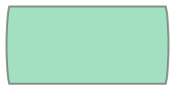

In [10]:
tracking_bounds

In [11]:
search = catalog.search(
    collections=EC_COLLECTION, 
    datetime=("2024-08-10", "2024-09-30"), 
    bbox=tracking_bounds.bounds, 
    filter="(productType = 'CPR_FMR_2A')",# or (productType = 'CPR_CD__2A')",
    method = 'GET', # This is necessary 
)

df = pd.DataFrame(
    data={"stac":list(search.items())}
)

df["granule"] = [f.id[-6:] for f in df.stac]
df["product"] = [f.id[9:19] for f in df.stac]
df["baseline"] = [f.id[6:8] for f in df.stac]
df["date"] = [
    pd.to_datetime(f.id[20:35], format="%Y%m%dT%H%M%S") for f in df.stac
]
df["enclosure_h5"] = [f.assets.get('enclosure_h5').href for f in df.stac]
df = df.sort_values(["date", "product"]).reset_index(drop=True)

In [12]:
import antimeridian
gdf = gpd.GeoDataFrame(
    df.drop("stac", axis=1), 
    geometry=[
        antimeridian.fix_line_string(
            shapely.LineString(row["stac"].geometry["coordinates"]), 
            great_circle=True,
        )
        for idx, row in df.iterrows()
    ], 
    crs="EPSG:4326"
)

In [14]:
granules = [df.granule.tolist() for _, df in gdf.groupby((gdf.date.diff() > np.timedelta64(15, "m")).cumsum())]

In [16]:
with open("../scripts/granules.lst", "w") as f:
    f.writelines(
        (" ".join(g)+"\n" for g in granules)
    )   